In [200]:
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from typing import TypedDict,Annotated
from langgraph.graph import  StateGraph,START,END
import re


In [201]:
class State(TypedDict):
    query:str
    result:str

In [202]:
@tool
def calculator(expression: str):
    """Perform mathematical calculations."""
    return str(eval(expression))

In [203]:
def calculator_node(state):

    query = state["query"]

    print("Query:", query)

    expression = re.sub(
        r"[^0-9+\-*/().]",
        "",
        query
    )

    print("Expression:", expression)

    result = calculator.invoke(
        {"expression": expression}
    )

    return {
        "result": result
    }

In [204]:
from datetime import datetime
@tool
def current_date(dummy:str):
    """Returns today date"""
    return datetime.now().strftime("%d-%m-%Y")

In [205]:

@tool
def knowledge_lookup(topic:str):
    """Return preferred Knowledge"""
    Knowledge={
        "ai": "Artificial Intelligence is the simulation of human intelligence by machines.",
        "python": "Python is a high-level programming language.",
        "langgraph": "LangGraph is a framework for building stateful AI workflows."
    }
    return Knowledge.get(
        topic.lower(),
        "Knowledge is not found"
    )

In [206]:
def route(state):
    query=state["query"].lower()


    if any(symbol in query 
           for symbol in ["+","-","/","*"]):
        return 'calculator'
    elif "date" in query:
        return 'date'
    
    return 'knowledge'

In [207]:
def date_node(state):

    result = current_date.invoke("")

    return {
        "result": result
    }

In [208]:
def knowledge_node(state):
    query = state["query"].lower()

    if "ai" in query:
        topic = "ai"
    elif "python" in query:
        topic = "python"
    elif "langgraph" in query:
        topic = "langgraph"
    else:
        topic = ""

    result = knowledge_lookup.invoke(topic)

    return {
        "result": result
    }

In [209]:
builder=StateGraph(State)
builder.add_node("calculator",calculator_node)
builder.add_node("date",date_node)
builder.add_node("knowledge",knowledge_node)

builder.add_conditional_edges(
    START,
    route,
    {
        "calculator":"calculator",
        "date":"date",
        "knowledge":"knowledge"
    }
)

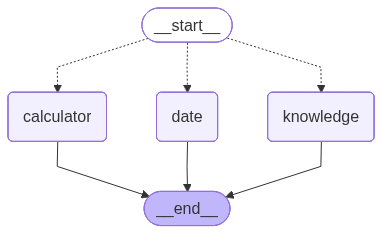

In [210]:
builder.add_edge("calculator",END)
builder.add_edge("date",END)
builder.add_edge("knowledge",END)

graph=builder.compile()
graph

In [211]:
graph.invoke({
    "query": "What is langgraph:"
})

{'query': 'What is langgraph:',
 'result': 'LangGraph is a framework for building stateful AI workflows.'}